# 數據容器

在 Python 中，有個**數據容器**（Container）的概念。

其中包括**字符串**、由 `range()` 函數生成的**等差數列**、**列表**（List）、**元組**（Tuple）、**集合**（Set）、**字典**（Dictionary）。

這些容器，各有各的用處。其中又分爲*可變*容器（Mutable）和*不可變*容器（Immutable）。可變的有列表、集合、字典；不可變的有字符串、`range()` 生成的等差數列、元組。集合，又分爲 *Set* 和 *Frozen Set*；其中，Set 是*可變的*，Frozen Set 是*不可變的*。

字符串、由 `range()` 函數生成的等差數列、列表、元組是**有序類型**（Sequence Type），而集合與字典是*無序*的。

![](images/python-containers-final.png)

另外，集合沒有*重合*元素。

## 迭代（Iterate）

數據容器裏的元素是可以被**迭代的**（Iterable），它們其中包含的元素，可以被逐個訪問，以便被處理。

對於數據容器，有一個操作符，`in`，用來判斷某個元素是否屬於某個容器。

由於數據容器的可迭代性，再加上這個操作符 `in`，在 Python 語言裏寫循環格外容易且方便（以字符串這個字符的容器作爲例子）：

In [1]:
for c in 'Python':
  print(c)

P
y
t
h
o
n


在 Python 出現之前，想要完成這樣一個訪問字符串中的每一個字符的循環，大抵上應該是這樣的（比如 C 語言）：

``` C
# Written in C
char *string;

scanf("%s",string); 
int i=strlen(string);
int k = 0;
while(k<i){    
      printf("%c", string[k]);
      k++;    
  }
 ```
 
 在 Python 中，簡單的 for 循環，只需要指定一個次數就可以了，因爲有 range() 這個函數：

In [2]:
for i in range(10):
  print(i)

0
1
2
3
4
5
6
7
8
9


即便是用比 C 更爲 “現代” 一點的 JavaScript，也大抵上應該是這樣的：

```c
var i;
for (i = 0; i < 10; i++) { 
  console.log(i)
}
```

當然，有時候我們也需要比較複雜的計數器，不過，Python 也不只有 `for` 循環，還有 `while` 循環，在必要的時候可以寫複雜的計數器。

## 列表（List）

列表和字符串一樣，是個*有序類型*（Sequence Type）的容器，其中包含着有索引編號的元素。

列表中的元素可以是不同類型。不過，在解決現實問題的時候，我們總是傾向於創建由同一個類型的數據構成的列表。遇到由不同類型數據構成的列表，我們更可能做的是想辦法把不同類型的數據分門別類地拆分出來，整理清楚 —— 這種工作甚至有個專門的名稱與之關聯：*數據清洗*。

### 列表的生成

生成一個列表，有以下幾種方式：


```python
a_list = []
b_list = [1, 2, 3]
list(), or list(iterable)            # 這是 Type Casting
[(expression with x) for x in iterable]
```

In [3]:
a_list = []
a_list.append(1)
a_list.append(2)
print(a_list, f'has a length of {len(a_list)}.')

#range() 返回的不是 list，需要用 list() 轉換，否則也沒辦法調用 .append()
b_list = list(range(1, 9))
b_list.append(11)
print(b_list, f'has a length of {len(b_list)}.')


c_list = [2**x for x in range(8)]
print(c_list, f'has a length of {len(c_list)}.')

[1, 2] has a length of 2.
[1, 2, 3, 4, 5, 6, 7, 8, 11] has a length of 9.
[1, 2, 4, 8, 16, 32, 64, 128] has a length of 8.


這最後一種方式頗爲神奇：

```python
[2**x for x in range(8)]
```

這種做法，叫做 **[List Comprehension](https://docs.python.org/3.7/tutorial/datastructures.html#tut-listcomps)**。

*Comprehend* 這個詞的意思除了 “理解” 之外，還有另外一個意思，就是 “包括、囊括” —— 這樣的話，你就大概能理解這種做法爲什麼被稱作 *List Comprehension* 了。中文翻譯中，怎麼翻譯的都有，“列表生成器”、“列表生成式” 等等，都挺好。但是，被翻譯成 “列表解析器”，就不太好了，給人的感覺是操作反了……

List comprehension 可以嵌套使用 `for`，甚至可以加上條件 `if`。官方文檔裏有個例子，是用來把兩個元素並不完全相同的列表去同後拼成一個列表（下面稍作了改寫）：


In [4]:
import random

n = 10 

# 生成一個 n 個元素的序列，每個元素是 1~100 之間的隨機數
a_list = [random.randrange(1, 100) for i in range(n)]
print(f'a_list comprehends {len(a_list)} random numbers: {a_list}')

# 從 a_list 裏把偶數都挑出來
b_list = [x for x in a_list if x % 2 == 0]
print(f'... and it has {len(b_list)} even numbers: {b_list}')

a_list comprehends 10 random numbers: [52, 34, 7, 96, 33, 79, 95, 18, 37, 46]
... and it has 5 even numbers: [52, 34, 96, 18, 46]


### 列表的操作符

列表的操作符和字符串一樣，因爲它們都是有序容器。列表的操作符有：

> * 拼接：`+`（與字符串不一樣的地方是，不能用空格 `' '` 了）
> * 複製：`*`
> * 邏輯運算：`in` 和 `not in`，`<`、`<=`、`>`、`>=`、`!=`、`==`

而後兩個列表也和兩個字符串一樣，可以被比較，即，可以進行邏輯運算；比較方式也跟字符串一樣，從兩個列表各自的第一個元素開始逐個比較，“一旦決出勝負馬上停止”：

In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

a_list = [1, 2, 3]
b_list = [4, 5, 6]
c_list = a_list + b_list * 3
c_list
7 not in c_list
a_list > b_list

[1, 2, 3, 4, 5, 6, 4, 5, 6, 4, 5, 6]

True

False

### 根據索引提取列表元素

列表當然也可以根據索引操作，但由於列表是可變序列，所以，不僅可以提取，還可以刪除，甚至替換。

In [6]:
import random
n = 3 
a_list = [random.randrange(65, 91) for i in range(n)]
b_list = [chr(random.randrange(65, 91)) for i in range(n)]
print(a_list)
c_list = a_list + b_list + a_list * 2
print(c_list)

print()
# 根據索引提取（Slicing）
print(c_list[3])        # 返回索引值爲 3 的元素值
print(c_list[:])        # 相當於 c_list，返回整個列表
print(c_list[5:])       # 從索引爲 5 的值開始直到末尾
print(c_list[:3])       # 從索引 0 開始，直到索引 3 之前（不包括 3）
print(c_list[2:6])      # 從索引 2 開始，直到索引 6 之前（不包括 6）

print()
# 根據索引刪除
del c_list[3]
print(c_list)           # del 是個命令，del c_list[3] 是一個語句；不能這麼寫：print(del c_list[3])
del c_list[5:8]         
print(c_list)

print()
# 根據索引替換
c_list[1:5:2] = ['a', 2]  # s[start:stop:step] = t，跟 range 的三個參數類似；
                         # len(t) = len([start:stop:step]) 必須爲真
print(c_list)

[77, 66, 79]
[77, 66, 79, 'L', 'Z', 'R', 77, 66, 79, 77, 66, 79]

L
[77, 66, 79, 'L', 'Z', 'R', 77, 66, 79, 77, 66, 79]
['R', 77, 66, 79, 77, 66, 79]
[77, 66, 79]
[79, 'L', 'Z', 'R']

[77, 66, 79, 'Z', 'R', 77, 66, 79, 77, 66, 79]
[77, 66, 79, 'Z', 'R', 77, 66, 79]

[77, 'a', 79, 2, 'R', 77, 66, 79]


需要注意的地方是：**列表**（List）是可變序列，而**字符串**（str）是不可變序列，所以，對字符串來說，雖然也可以根據索引提取，但沒辦法根據索引刪除或者替換。

In [7]:
s = 'Python'[2:5]
print(s)
del s[2]  # 這一句會報錯

tho


TypeError: 'str' object doesn't support item deletion

之前提到過：

> 字符串常量（String Literal）是不可變有序容器，所以，雖然字符串也有一些 Methods 可用，但那些 Methods 都不改變它們自身，而是在操作後返回一個值給另外一個變量。

而對於列表這種*可變容器*，我們可以對它進行操作，結果是*它本身被改變*了。

In [8]:
s = 'Python'
L = list(s)
print(s)
print(L)
del L[2]
print(L) # 用 del 對 L 操作之後，L 本身少了 1 個元素

Python
['P', 'y', 't', 'h', 'o', 'n']
['P', 'y', 'h', 'o', 'n']


### 列表可用的內建函數

列表和字符串都是容器，它們可使用的內建函數也其實都是一樣的：

> * `len()`
> * `max()`
> * `min()`

In [9]:
import random
n = 3 

# 生成 3 個隨機數，構成一個列表
a_list = [random.randrange(65, 91) for i in range(n)]
b_list = [chr(random.randrange(65, 91)) for i in range(n)]
print(a_list)
print(b_list)

# 列表可以使用操作符 + 和*
c_list = a_list + b_list + a_list * 2
print(c_list)

a_list *= 3
print(a_list)

# 內建函數操作 len()、max()、min()
print(len(c_list))
print(max(b_list)) # 內建函數內部做了異常處理，可以在字符之間或者數字之間進行比較 —— 初學者最討厭這種事情了……
print(min(b_list)) # 注意，max() 和 min() 應用的是 b_list, len() 應用的是 c_list —— 請自行找到對應的 list 進行分析。

print('X' not in b_list)

[89, 84, 85]
['X', 'B', 'X']
[89, 84, 85, 'X', 'B', 'X', 89, 84, 85, 89, 84, 85]
[89, 84, 85, 89, 84, 85, 89, 84, 85]
12
X
B
False


### Methods

字符串常量和 range() 都是不可變的（Immutable）；而列表則是**可變類型**（Mutable type），所以，它最起碼可以被排序 —— 使用 `sort()` Method：

In [10]:
import random
n = 10 
a_list = [random.randrange(1, 100) for i in range(n)]
print(f'a_list comprehends {len(a_list)} random numbers:\n', a_list)

a_list.sort()
print('the list sorted:\n', a_list)

a_list.sort(reverse=True) #reverse 參數，默認是 False
print('the list sorted reversely:\n', a_list)

a_list comprehends 10 random numbers:
 [98, 9, 95, 15, 80, 70, 98, 82, 88, 46]
the list sorted:
 [9, 15, 46, 70, 80, 82, 88, 95, 98, 98]
the list sorted reversely:
 [98, 98, 95, 88, 82, 80, 70, 46, 15, 9]


如果列表中的元素全都是由字符串構成的，當然也可以排序：

In [11]:
import random
n = 10 

a_list = [chr(random.randrange(65, 91)) for i in range(n)]
# chr() 函數會返回指定 ascii 碼的字符，ord('A') 是 65
print(f'a_list comprehends {len(a_list)} random string elements:\n', a_list)

a_list.sort()
print('the list sorted:\n', a_list)

a_list.sort(reverse=True) #reverse 參數，默認是 False
print('the list sorted reversely:\n', a_list)

print()

b_list = [chr(random.randrange(65, 91)) +\
            chr(random.randrange(97, 123))\
            for i in range(n)]
# 可以在行末加上 \ 符號，表示 “該行未完待續……”

print(f'b_list comprehends {len(b_list)} random string elements:\n', b_list)

b_list.sort()
print('the sorted:\n', b_list)

b_list.sort(key=str.lower, reverse=True) 
# key 參數，默認是 None
# key=str.lower 的意思是，在比較的時候，先全都轉換成小寫再比較……
# —— 但並不改變原有值
print('the sorted reversely:\n', b_list)

a_list comprehends 10 random string elements:
 ['B', 'U', 'H', 'D', 'C', 'V', 'V', 'Q', 'U', 'P']
the list sorted:
 ['B', 'C', 'D', 'H', 'P', 'Q', 'U', 'U', 'V', 'V']
the list sorted reversely:
 ['V', 'V', 'U', 'U', 'Q', 'P', 'H', 'D', 'C', 'B']

b_list comprehends 10 random string elements:
 ['Nl', 'Mh', 'Ta', 'By', 'Ul', 'Nc', 'Gu', 'Rp', 'Pv', 'Bu']
the sorted:
 ['Bu', 'By', 'Gu', 'Mh', 'Nc', 'Nl', 'Pv', 'Rp', 'Ta', 'Ul']
the sorted reversely:
 ['Ul', 'Ta', 'Rp', 'Pv', 'Nl', 'Nc', 'Mh', 'Gu', 'By', 'Bu']


**注意**：不能亂比較…… 被比較的元素應該是同一類型 —— 所以，不是由同一種數據類型元素構成的列表，不能使用 `sort()` Method。下面的代碼會報錯：

In [12]:
a_list = [1, 'a', 'c']
a_list = a_list.sort() # 這一句會報錯

TypeError: '<' not supported between instances of 'str' and 'int'

**可變序列**還有一系列可用的 **Methods**：`a.append()`，`a.clear()`，`a.copy()`，`a.extend(t)`，`a.insert(i，x)`，`a.pop([i])`，`a.remove(x)`，`a.reverse()`……

In [13]:
import random
n = 3 
a_list = [random.randrange(65, 91) for i in range(n)]
b_list = [chr(random.randrange(65, 91)) for i in range(n)]
print(a_list)
c_list = a_list + b_list + a_list * 2
print(c_list)

# 在末尾追加一個元素
c_list.append('100')
print(c_list)

# 清空序列
print()
print(a_list)
a_list.clear()
print(a_list)

print()
# 拷貝一個列表
d_list = c_list.copy()
print(d_list)
del d_list[6:8]
print(d_list)
print(c_list)             # 對一個拷貝操作，不會更改 “原件”

print()
# 演示拷貝 .copy() 與賦值 = 的不同
e_list = d_list
del e_list[6:8]
print(e_list)
print(d_list)             # 對 e_list 操作，相等於對 d_list 操作

# 在末尾追加一個列表
print()
print(a_list)
a_list.extend(c_list)      # 相當於 a_list += c_list
print(a_list)

# 在某索引位置插入一個元素
print()
print(a_list)
a_list.insert(1, 'example')   # 在索引 1 的位置插入 'example'
a_list.insert(3, 'example')   # 在索引 3 的位置插入 'example'；
print(a_list)

# 排序

# a_list.sort() 這一句會出錯，因爲當前列表中的元素，是 int 和 str 混合的。

print()
print(a_list)
a_list.reverse()
print(a_list)
x = a_list.reverse() # reverse() 只對當前序列操作，並不返回一個逆序列表；返回值是 None
print(x)

[90, 88, 73]
[90, 88, 73, 'T', 'N', 'Y', 90, 88, 73, 90, 88, 73]
[90, 88, 73, 'T', 'N', 'Y', 90, 88, 73, 90, 88, 73, '100']

[90, 88, 73]
[]

[90, 88, 73, 'T', 'N', 'Y', 90, 88, 73, 90, 88, 73, '100']
[90, 88, 73, 'T', 'N', 'Y', 73, 90, 88, 73, '100']
[90, 88, 73, 'T', 'N', 'Y', 90, 88, 73, 90, 88, 73, '100']

[90, 88, 73, 'T', 'N', 'Y', 88, 73, '100']
[90, 88, 73, 'T', 'N', 'Y', 88, 73, '100']

[]
[90, 88, 73, 'T', 'N', 'Y', 90, 88, 73, 90, 88, 73, '100']

[90, 88, 73, 'T', 'N', 'Y', 90, 88, 73, 90, 88, 73, '100']
[90, 'example', 88, 'example', 73, 'T', 'N', 'Y', 90, 88, 73, 90, 88, 73, '100']

[90, 'example', 88, 'example', 73, 'T', 'N', 'Y', 90, 88, 73, 90, 88, 73, '100']
['100', 73, 88, 90, 73, 88, 90, 'Y', 'N', 'T', 73, 'example', 88, 'example', 90]
None


有一個命令、兩個 Methods 與刪除單個元素相關聯，`del`，`a.pop([i])`，`a.remove(x)`，請注意它們之間的區別。

In [14]:
import random
n = 3 
a_list = [random.randrange(65, 91) for i in range(n)]
print(a_list)

# 插入
print()
a_list.insert(1, 'example')   # 在索引 1 的位置插入 'example'

# 刪除
print()
print(a_list)
a_list.remove('example')      # 去除 'example' 這個元素，如果有多個 'example'，只刪除第一個
print(a_list)

# pop() 刪除並返回被刪除的值

print()
print(a_list)
p = a_list.pop(2)      # 去除索引爲 2 的元素，且返回元素的值，賦值給 p
print(a_list)
print(p)

# pop() 與 del，或者 remove() 的區別
print()
a_list.insert(2, 'example')
a_list.insert(2, 'example')
print(a_list)
del a_list[2]
print(a_list)

print()
print(a_list.remove('example')) # a_list.remove() 這個 Method 的返回值是 None
print(a_list)

[88, 84, 69]


[88, 'example', 84, 69]
[88, 84, 69]

[88, 84, 69]
[88, 84]
69

[88, 84, 'example', 'example']
[88, 84, 'example']

None
[88, 84]


### 小結

看起來是個新概念，例子全部讀完也很是要花上一段時間，然而，從操作上來看，操作列表和操作字符串的差異並不大，重點在於一個是 Immutable，另外一個是 Mutable，所以，例如像 `a.sort()`，`a.remove()` 這樣的事，列表能做，字符串不能做 —— 字符串也可以排序，但那是排序之後返回給另外一個變量；而列表可以直接改變自身……

而整理成表格之後呢，理解與記憶真的是零壓力：

![](images/list-concepts.png)

## 元組（Tuple）

在完整掌握列表的創建與操作之後，再理解元組（Tuple）就容易了，因爲它們之間的主要區別只有兩個：

> * List 是*可變*有序容器，Tuple 是*不可變*有序容器。
> * List 用*方括號*標識 `[]`，Tuple 用*圓括號* 標識 `()`。

創建一個元組的時候，用圓括號：

```python
a = ()
``` 

這樣就創建了一個空元組。

多個元素之間，用 `,` 分離。

創建一個含多個元素的元組，可以省略這個括號。

In [15]:
a = 1, 2, 3   # 不建議這種寫法
b = (1, 2, 3) # 在創建元組的時候建議永遠不省略圓括號……
print(a)
print(b)
a == b

(1, 2, 3)
(1, 2, 3)


True

**注意**：創建單個元素的元組，無論是否使用圓括號，在那唯一的元素後面一定要*補上一個逗號* `,`：

In [16]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

a = 2, # 注意這個末尾的逗號 , 它使得 a 變量被定義爲一個元組，而不是數字
a

b = 2  # 整數，賦值
b

c = (2) # 不是元組
c
type(c) # 還是 int

d = (2,) # 這纔是元組
d
a == d

(2,)

2

2

int

(2,)

True

元組是不可變序列，所以，你沒辦法從裏面刪除元素。

但是，你可以在末尾追加元素。所以，嚴格意義上，對元組來講，“不可變” 的意思是說，“**當前已有部分不可變**”……

In [17]:
a = 1, 
print(a)
print(id(a))
a += 3, 5
print(a)
print(id(a)) # id 並不相同 —— 實際上是在內存中另外新創建了一個元組……

(1,)
4593032496
(1, 3, 5)
4592468976


初學者總是很好奇 List 和 Tuple 的區別。首先是使用場景，在將來需要更改的時候，創建 List
；在將來不需要更改的時候，創建 Tuple。其次，從計算機的角度來看，Tuple 相對於 List 佔用更小的內存。

In [18]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

n = 10000 #@param {type:"number"}
a = range(n)
b = tuple(a) # 把 a 轉換成元組
c = list(a) # 把 a 轉換成列表
a.__sizeof__()
b.__sizeof__()
c.__sizeof__()

48

80024

90088

等你瞭解了 Tuple 的標註方式，你就會發現，`range()` 函數返回的等差數列就是一個 Tuple —— `range(6)` 就相當於 `(0, 1, 2, 3, 4, 5)`。

## 集合（Set）

**集合**（Set）這個容器類型與列表不同的地方在於，首先它*不包含重合元素*，其次它是*無序*的；進而，集合又分爲兩種，Set，*可變的*，Frozen Set，*不可變的*。

創建一個集合，用**花括號** `{}` 把元素括起來，用 `,` 把元素隔開：

In [19]:
primes = {2, 3, 5, 7, 11, 13, 17}
primes

{2, 3, 5, 7, 11, 13, 17}

### 創建

注意：創建空集合的時候，必須用 `set()`，而不能用 `{}`:

In [20]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

a = {} # 注意這樣創建的是一個 dict（字典），而不是 set 集合
b = set() # 這樣創建的纔是空集合
type(a)
type(b)

dict

set

也可以將序列數據轉換（Casting）爲集合。轉換後，返回的是一個已**去重**的集合。

In [21]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

a = "abcabcdeabcdbcdef"
b = range(10)
c = [1, 2, 2, 3, 3, 1]
d = ('a', 'b', 'e', 'b', 'a')
set(a)
set(b)
set(c)
set(d)

{'a', 'b', 'c', 'd', 'e', 'f'}

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

{1, 2, 3}

{'a', 'b', 'e'}

Set 當然也可以進行 *Comprehension*：

In [22]:
a = "abcabcdeabcdbcdef"
b = {x for x in a if x not in 'abc'}
b

{'d', 'e', 'f'}

### 操作

將序列類型數據轉換成 Set，就等於**去重**。當然，也可以用 `in` 來判斷某個元素是否屬於這個集合。`len()`、`max()`、`min()`，也都可以用來操作 Set，但 `del` 卻不行 —— 因爲 Set 中的元素沒有索引（它不是有序容器）。從 Set 裏刪除元素，得用 `set.remove(elem)`；而 Frozen Set 是不可變的，所以不能用 `set.remove(elem)` 操作。

對於集合，有相應的操作符可以對它們進行集合運算：

> * 並集：`|`
> * 交集：`&`
> * 差集：`-`
> * 對稱差集：`^`

之前用 `set('abcabcdeabcdbcdef')` 作爲簡單例子還湊合能用；但這樣對讀者無意義的集合，無助於進一步的理解。

事實上，每種數據結構（Data Structures —— 在這一章裏，我們一直用的概念是 “容器”，其實是指同一事物的兩種稱呼）都有自己的應用場景。比如，當我們需要管理很多用戶時，集合就可以派上很大用場。

假定兩個集合中有些人是 admins，有些人是 moderators：

```python
admins = {'Moose', 'Joker', 'Joker'}
moderators = {'Ann', 'Chris', 'Jane', 'Moose', 'Zero'}
```

那麼：

In [23]:
admins = {'Moose', 'Joker', 'Joker'}
moderators = {'Ann', 'Chris', 'Jane', 'Moose', 'Zero'}

admins                 # 去重自動完成
'Joker' in admins      # Joker 是否是 admins？
'Joker' in moderators  # Joker 是否是 moderator？
admins | moderators    # admins、moderator，或者身兼兩職的，即，兩個角色中的所有人 in admins or moderators or both
admins & moderators    # 既是 admins 又是 moderator 的都有誰？in both admins and moderators
admins - moderators    # 是 admins 但不是 moderator 的都有誰？in admins but not in moderators
admins ^ moderators    # admins 和 moderator 中不是身兼兩職的都有誰？in admins or moderator but not both

{'Joker', 'Moose'}

True

False

{'Ann', 'Chris', 'Jane', 'Joker', 'Moose', 'Zero'}

{'Moose'}

{'Joker'}

{'Ann', 'Chris', 'Jane', 'Joker', 'Zero'}

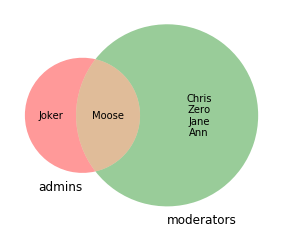

In [49]:
# 這個 cell 集合運算圖示需要安裝 matplotlib 和 matplotlib-venn
# !pip install matplotlib
# !pip install matplotlib-venn
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

admins = {'Moose', 'Joker', 'Joker'}
moderators = {'Ann', 'Chris', 'Jane', 'Moose', 'Zero'}

v = venn2(subsets=(admins, moderators), set_labels=('admins', 'moderators'))
v.get_label_by_id('11').set_text('\n'.join(admins & moderators))
v.get_label_by_id('10').set_text('\n'.join(admins - moderators))
v.get_label_by_id('01').set_text('\n'.join(moderators - admins))

plt.show()

以上的操作符，都有另外一個版本，即，用 Set 這個類的 Methods 完成。

|   意義    | 操作符 | Methods                    | Methods 相當於 |
| :------: | :----: | :---------------------: | :--: |
| 並集     | <code>&#124;</code>    | `set.union(*others)`         | <code>set &#124; other &#124; ...</code> |
| 交集     | `&`    | `set.intersection(*others)` | `set & other & ...` |
| 差集     | `-`    | `set.difference(*others)` | `set - other - ...` |
| 對稱差集 | `^`    | `set.symmetric_difference(other)` | `set ^ other` |

注意，並集、交集、差集的 Methods，可以接收多個集合作爲參數 `(*other)`，但對稱差集 Method 只接收一個參數 `(other)`。

對於集合，推薦更多使用 Methods 而不是操作符的主要原因是：更易讀 —— 對人來說，因爲有意義、有用處的代碼終將需要人去維護。

In [26]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

admins = {'Moose', 'Joker', 'Joker'}
moderators = {'Chris', 'Moose', 'Jane', 'Zero'}

admins.union(moderators)
admins.intersection(moderators)
admins.difference(moderators)
admins.symmetric_difference(moderators)

{'Chris', 'Jane', 'Joker', 'Moose', 'Zero'}

{'Moose'}

{'Joker'}

{'Chris', 'Jane', 'Joker', 'Zero'}

### 邏輯運算

兩個集合之間可以進行邏輯比較，返回布爾值。

**set** `==` **other**
> `True`: set 與 other 相同

**set** `!=` **other**
> `True`: set 與 other 不同

**isdisjoint**(_other_)
> `True`: set 與 other 非重合；即，`set & other == None`

**issubset**(_other_)，**set** `<=` **other**
> `True`: set 是 other 的子集

**set** `<` **other**
> `True`: set 是 other 的真子集，相當於 `set <= other && set != other`

**issuperset**(_other_)，**set** `>=` **other**
> `True`: set 是 other 的超集

**set** `>` **other**
> `True`: set 是 other 的真超集，相當於 `set >= other && set != other`

### 更新

對於集合，有以下更新它自身的 Method：

**add**(*elem*)
> 把 elem 加入集合

**remove**(*elem*)
> 從集合中刪除 elem；如果集合中不包含該 elem，會產生 KeyError 錯誤。

**discard**(*elem*)
> 如果該元素存在於集合中，刪除它。

**pop**()
> 從集合中隨機刪除一個元素，並返回刪除的元素的值，針對空集合做此操作會產生 KeyError 錯誤。

**clear**()
從集合中刪除所有元素。

**set.update**(*_others_)，相當於 `set |= other | ...`
> 更新 set, 加入 others 中的所有元素；

**set.intersection_update**(*_others_)，相當於 `set &= other & ...`
> 更新 set, 保留同時存在於 set 和所有 others 之中的元素；

**set.difference_update**(*_others_)，相當於 `set -= other | ...`
> 更新 set, 刪除所有在 others 中存在的元素；

**set.symmetric_difference_update**(_other_)，相當於 `set ^= other`
> 更新 set, 只保留存在於 set 或 other 中的元素，但不保留同時存在於 set 和 other 中的元素；**注意**，該 Method *只接收一個參數*。

### 凍結集合

還有一種集合，叫做凍結集合（Frozen Set），Frozen Set 之於 Set，正如 Tuple 之於 List，前者是不可變容器（Immutable），後者是可變容器（Mutable），無非是爲了節省內存使用而設計的類別。

有空去看看這個鏈接就可以了：

> https://docs.python.org/3/library/stdtypes.html#frozenset

## 字典（Dictionary）

Map 是容器中的單獨一類，**映射**（Map）容器。映射容器只有一種，叫做**字典**（Dictionary）。先看一個例子：

In [ ]:
phonebook = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225}
phonebook

字典裏的每個元素，由兩部分組成，_key_（鍵）和 _value_（值），二者由一個冒號連接。

比如，`'ann':6575` 這個字典元素，_key_ 是 `'ann'`，_value_ 是 `6575`。

字典直接使用 _key_ 作爲索引，並映射到與它匹配的 _value_：

In [28]:
phonebook = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225}
phonebook['bob']

8982

在同一個字典裏，_key_ 都是唯一的。當創建字典的時候，如果其中有重複的 _key_ 的話，就跟 Set 那樣會 “**自動去重**” —— 保留的是衆多重複的 _key_ 中的最後一個 _key:value_（或者說，最後一個 _key:value_ “之前那個 _key_ 的 _value_ 被**更新**了”）。字典這個數據類型之所以叫做 Map（映射），是因爲字典裏的 _key_ 都映射且只映射一個對應的 _value_。

In [29]:
phonebook = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}
phonebook

{'ann': 6585, 'bob': 8982, 'joe': 2598, 'zoe': 1225}

在已經瞭解如何操作列表之後，再去理解字典的操作，其實沒什麼難度，無非就是字典多了幾個 Methods。

提蓄一下自己的耐心，把下面的若干行代碼都仔細閱讀一下，猜一猜輸出結果都是什麼？

### 字典的生成

In [30]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

aDict = {}
bDict = {'a':1, 'b':2, 'c':3}
aDict
bDict

{}

{'a': 1, 'b': 2, 'c': 3}

### 更新某個元素

In [31]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

phonebook1 = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}

phonebook1['joe']
phonebook1['joe'] = 5802
phonebook1
phonebook1['joe']

2598

{'ann': 6585, 'bob': 8982, 'joe': 5802, 'zoe': 1225}

5802

### 添加元素

In [32]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

phonebook1 = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}
phonebook2 = {'john':9876, 'mike':5603, 'stan':6898, 'eric':7898}

phonebook1.update(phonebook2)
phonebook1

{'ann': 6585,
 'bob': 8982,
 'joe': 2598,
 'zoe': 1225,
 'john': 9876,
 'mike': 5603,
 'stan': 6898,
 'eric': 7898}

### 刪除某個元素

In [33]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

phonebook1 = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}

del phonebook1['ann']
phonebook1

{'bob': 8982, 'joe': 2598, 'zoe': 1225}

### 邏輯操作符

In [34]:
phonebook1 = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}

'ann' in phonebook1

phonebook1.keys()
'stan' in phonebook1.keys()

phonebook1.values()
1225 in phonebook1.values()

phonebook1.items()
('stan', 6898) in phonebook1.items()

True

dict_keys(['ann', 'bob', 'joe', 'zoe'])

False

dict_values([6585, 8982, 2598, 1225])

True

dict_items([('ann', 6585), ('bob', 8982), ('joe', 2598), ('zoe', 1225)])

False

### 可用來操作的內建函數

In [35]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

phonebook1 = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}
phonebook2 = {'john':9876, 'mike':5603, 'stan':6898, 'eric':7898}
phonebook1.update(phonebook2)

len(phonebook1)
max(phonebook1)
min(phonebook1)
list(phonebook1)
tuple(phonebook1)
set(phonebook1)
sorted(phonebook1)
sorted(phonebook1, reverse=True)

8

'zoe'

'ann'

['ann', 'bob', 'joe', 'zoe', 'john', 'mike', 'stan', 'eric']

('ann', 'bob', 'joe', 'zoe', 'john', 'mike', 'stan', 'eric')

{'ann', 'bob', 'eric', 'joe', 'john', 'mike', 'stan', 'zoe'}

['ann', 'bob', 'eric', 'joe', 'john', 'mike', 'stan', 'zoe']

['zoe', 'stan', 'mike', 'john', 'joe', 'eric', 'bob', 'ann']

### 常用 Methods

In [36]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

phonebook1 = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}
phonebook2 = {'john':9876, 'mike':5603, 'stan':6898, 'eric':7898}

phonebook3 = phonebook2.copy()
phonebook3

phonebook3.clear()
phonebook3

phonebook2                      # .copy() 的 “原件” 不會發生變化

p = phonebook1.popitem()
p
phonebook1

p = phonebook1.pop('adam', 3538)
p
phonebook1

p = phonebook1.get('adam', 3538)
p
phonebook1

p = phonebook1.setdefault('adam', 3538)
p
phonebook1

{'john': 9876, 'mike': 5603, 'stan': 6898, 'eric': 7898}

{}

{'john': 9876, 'mike': 5603, 'stan': 6898, 'eric': 7898}

('zoe', 1225)

{'ann': 6585, 'bob': 8982, 'joe': 2598}

...

{'ann': 6585, 'bob': 8982, 'joe': 2598}

3538

{'ann': 6585, 'bob': 8982, 'joe': 2598}

3538

{'ann': 6585, 'bob': 8982, 'joe': 2598, 'adam': 3538}

## 迭代各種容器中的元素

我們總是有這樣的需求：對容器中的元素逐一進行處理（運算）。這樣的時候，我們就用 `for` 循環去迭代它們。

對於迭代 `range()` 和 `list` 中的元素我們已經很習慣了：

In [37]:
for i in range(3):
    print(i)

0
1
2


In [38]:
for i in [1, 2, 3]:
    print(i)

1
2
3


### 迭代的同時獲取索引

有時，我們想同時得到有序容器中的元素及其索引，那麼可以調用 `enumerate()` 函數來幫我們：

In [39]:
s = 'Python'
for i, c in enumerate(s):
    print(i, c)
    

0 P
1 y
2 t
3 h
4 o
5 n


In [40]:
for i, v in enumerate(range(3)):
    print(i, v)

0 0
1 1
2 2


In [41]:
L = ['ann', 'bob', 'joe', 'john', 'mike']
for i, L in enumerate(L):
    print(i, L)

0 ann
1 bob
2 joe
3 john
4 mike


In [42]:
t = ('ann', 'bob', 'joe', 'john', 'mike')
for i, t in enumerate(t):
    print(i, t)

0 ann
1 bob
2 joe
3 john
4 mike


### 迭代前排序

可以用 `sorted()` 和 `reversed()` 在迭代前先排好序：

In [43]:
t = ('bob', 'ann', 'john', 'mike', 'joe')
for i, t in enumerate(sorted(t)):
    print(i, t)

0 ann
1 bob
2 joe
3 john
4 mike


In [44]:
t = ('bob', 'ann', 'john', 'mike', 'joe')
for i, t in enumerate(sorted(t, reverse=True)):
    print(i, t)

0 mike
1 john
2 joe
3 bob
4 ann


In [45]:
t = ('bob', 'ann', 'john', 'mike', 'joe')
for i, t in enumerate(reversed(t)):
    print(i, t)

0 joe
1 mike
2 john
3 ann
4 bob


### 同時迭代多個容器

可以在 `zip()` 這個函數的幫助下，同時迭代兩個或者兩個以上的容器中的元素（這樣做的前提是，多個容器中的元素數量最好相同）：

In [46]:
chars = 'abcdefghijklmnopqrstuvwxyz'
nums = range(1, 27)
for c, n in zip(chars, nums):
    print(f"Let's assume {c} represents {n}.")

Let's assume a represents 1.
Let's assume b represents 2.
Let's assume c represents 3.
Let's assume d represents 4.
Let's assume e represents 5.
Let's assume f represents 6.
Let's assume g represents 7.
Let's assume h represents 8.
Let's assume i represents 9.
Let's assume j represents 10.
Let's assume k represents 11.
Let's assume l represents 12.
Let's assume m represents 13.
Let's assume n represents 14.
Let's assume o represents 15.
Let's assume p represents 16.
Let's assume q represents 17.
Let's assume r represents 18.
Let's assume s represents 19.
Let's assume t represents 20.
Let's assume u represents 21.
Let's assume v represents 22.
Let's assume w represents 23.
Let's assume x represents 24.
Let's assume y represents 25.
Let's assume z represents 26.


### 迭代字典中的元素

In [47]:
phonebook1 = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}

for key in phonebook1:
    print(key, phonebook1[key])

ann 6585
bob 8982
joe 2598
zoe 1225


In [48]:
phonebook1 = {'ann':6575, 'bob':8982, 'joe':2598, 'zoe':1225, 'ann':6585}

for key, value in phonebook1.items():
    print(key, value)

ann 6585
bob 8982
joe 2598
zoe 1225


## 總結

這一章的內容，只不過是 “多” 而已，一旦邏輯關係理順，就會覺得很簡單。而這一章的開頭，已經是最好的總結了。

最後需要補充的，只是兩個參考鏈接，以後有什麼搞不明白的地方，去那裏翻翻就能找到答案：

> * https://docs.python.org/3/tutorial/datastructures.html#dictionaries
> * https://docs.python.org/3/library/stdtypes.html#typesmapping

<a href="./Part.1.E.7.files.ipynb" ><small>Next Page</small></a>